
Model: MiniLM
Cosine Similarity Matrix:
tensor([[1.0000, 0.1818, 0.1376, 0.6246],
        [0.1818, 1.0000, 0.0153, 0.1249],
        [0.1376, 0.0153, 1.0000, 0.0992],
        [0.6246, 0.1249, 0.0992, 1.0000]])

Model: MPNet
Cosine Similarity Matrix:
tensor([[ 1.0000,  0.0665, -0.0031,  0.6248],
        [ 0.0665,  1.0000,  0.0928,  0.0506],
        [-0.0031,  0.0928,  1.0000, -0.0092],
        [ 0.6248,  0.0506, -0.0092,  1.0000]])

Model: DistilRoBERTa
Cosine Similarity Matrix:
tensor([[ 1.0000,  0.0759, -0.0315,  0.5088],
        [ 0.0759,  1.0000, -0.0274,  0.0689],
        [-0.0315, -0.0274,  1.0000,  0.0421],
        [ 0.5088,  0.0689,  0.0421,  1.0000]])


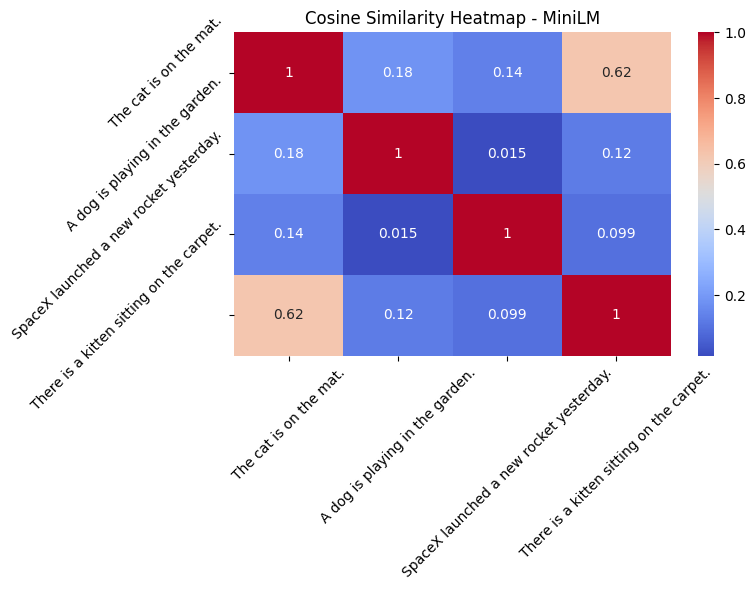

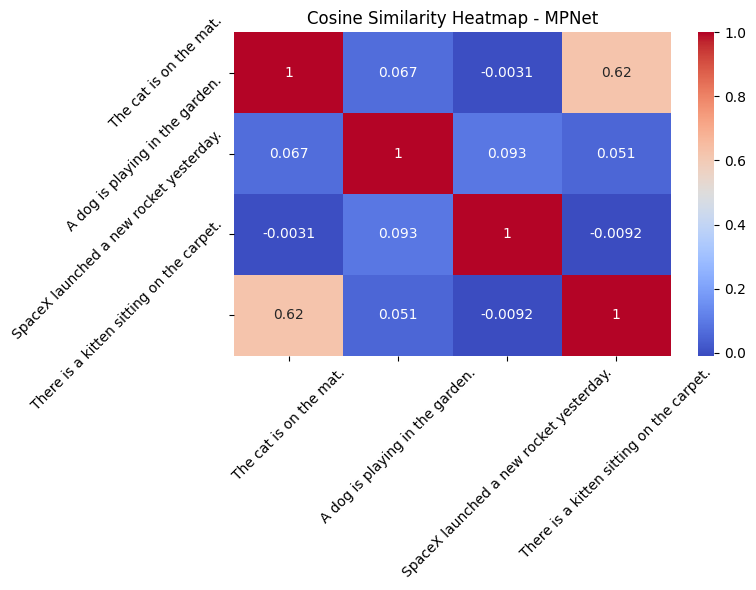

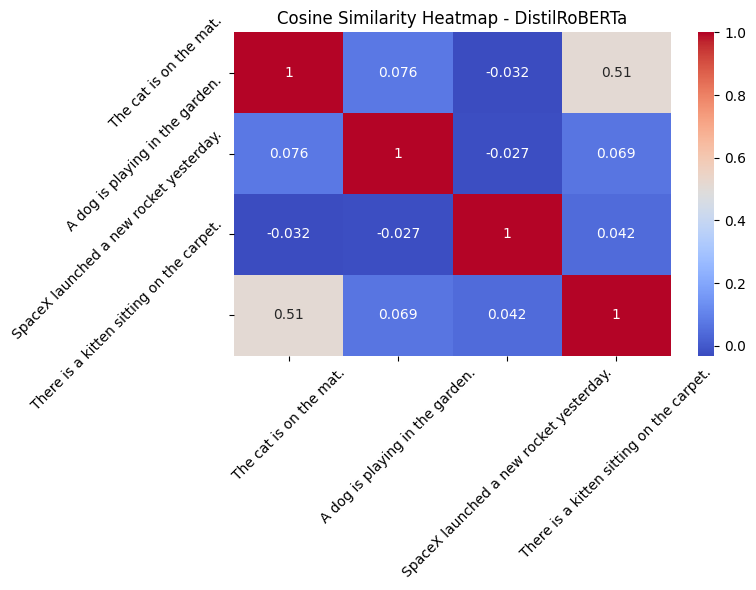

In [3]:
from sentence_transformers import SentenceTransformer, util
import numpy as np


# Load different Hugging Face sentence transformer models
models = {
    "MiniLM": SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2'),
    "MPNet": SentenceTransformer('sentence-transformers/all-mpnet-base-v2'),
    "DistilRoBERTa": SentenceTransformer('sentence-transformers/all-distilroberta-v1')
}


sentences = [
    "The cat is on the mat.",
    "A dog is playing in the garden.",
    "SpaceX launched a new rocket yesterday.",
    "There is a kitten sitting on the carpet."
]



from sklearn.metrics.pairwise import cosine_similarity

for model_name, model in models.items():
    print(f"\nModel: {model_name}")
    
    embeddings = model.encode(sentences, convert_to_tensor=True)
    similarity = util.cos_sim(embeddings, embeddings)
    
    print("Cosine Similarity Matrix:")
    print(similarity)


import seaborn as sns
import matplotlib.pyplot as plt

def plot_similarity(similarity, model_name):
    plt.figure(figsize=(8, 6))
    sns.heatmap(similarity, annot=True, xticklabels=sentences, yticklabels=sentences, cmap='coolwarm')
    plt.title(f"Cosine Similarity Heatmap - {model_name}")
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

for model_name, model in models.items():
    embeddings = model.encode(sentences)
    similarity = cosine_similarity(embeddings)
    plot_similarity(similarity, model_name)
